In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import keras  # 반드시 환경 변수 설정 이후에 import

print(keras.config.backend())  # 'torch' 출력

tensorflow


In [2]:
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

In [3]:
train_input.shape

(60000, 28, 28)

In [4]:
train_target.shape

(60000,)

In [5]:
test_input.shape

(10000, 28, 28)

In [6]:
test_target.shape

(10000,)

In [7]:
import matplotlib.pyplot as plt
import numpy as np

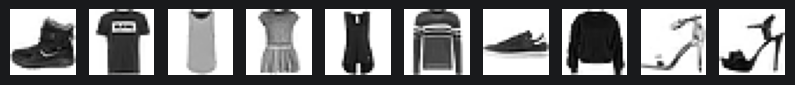

In [8]:
fig, axs = plt.subplots(1, 10, figsize = (10, 10))
for i in range(10):
    axs[i].imshow(train_input[i], cmap='gray_r')
    axs[i].axis('off')
plt.show()

In [9]:
train_target[:10]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5], dtype=uint8)

In [10]:
np.unique(train_target, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

In [11]:
train_scaled = train_input / 255.0

In [12]:
train_scaled = train_scaled.reshape(-1, 28*28)

In [13]:
train_scaled.shape

(60000, 784)

In [14]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import SGDClassifier

In [15]:
# epochsData = []
#
# for i in [5, 10, 20]:
#     sc = SGDClassifier(loss='log_loss', max_iter=i, random_state=42)
#     scores = cross_validate(sc, train_scaled, train_target, n_jobs=-1)
#     epochsData.append(np.mean(scores['test_score']))

In [16]:
# epochsData
# [np.float64(0.8191833333333334),
# np.float64(0.8312999999999999),
# np.float64(0.8442833333333333)]

In [17]:
keras.config.backend()

'tensorflow'

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
train_scaled, val_scaled, train_target, val_target = train_test_split(train_scaled, train_target, test_size=0.2, random_state=42)

In [20]:
train_scaled.shape

(48000, 784)

In [21]:
train_target.shape

(48000,)

In [22]:
val_scaled.shape

(12000, 784)

In [23]:
val_target.shape

(12000,)

In [34]:
import tensorflow as tf
from keras.models import Model  # 또는 Sequentiala

In [25]:
inputs = keras.layers.Input(shape=(784,))

In [26]:
dense = keras.layers.Dense(10, activation='softmax')

In [27]:
model = keras.Sequential([inputs, dense])

In [28]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [29]:
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 413us/step - accuracy: 0.7958 - loss: 0.6046  
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 378us/step - accuracy: 0.8392 - loss: 0.4742
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 386us/step - accuracy: 0.8472 - loss: 0.4507
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 363us/step - accuracy: 0.8511 - loss: 0.4381
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 365us/step - accuracy: 0.8546 - loss: 0.4298


In [35]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 406us/step - accuracy: 0.8462 - loss: 0.4472 


[0.4472063481807709, 0.8461666703224182]